# Aanwezigheidsanalyse: groepswerken versus gewone vakken

Deze notebook leest alle gegevens rechtstreeks uit het datawarehouse.

De pipeline:

1. maakt verbinding met SQL Server;
2. leest `group_projects.csv` en `non_group_projects.csv`;
3. haalt alle lesmomenten van Toegepaste Informatica uit `FactLecture`;
4. zoekt automatisch naar een tabel of view met aanwezigheidsgegevens per `LectureID`;
5. koppelt planning en aanwezigheid;
6. splitst de lessen in **groepswerken** en **gewone vakken**;
7. berekent gemiddelde, mediaan, spreiding, kwartielen, percentielen en andere statistieken;
8. exporteert controle- en resultaatbestanden.

> Controleer vooral de configuratiecel en de cel waarin de automatisch gekozen aanwezigheidsbron wordt weergegeven.


In [75]:
from pathlib import Path
import re
import unicodedata
import warnings
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 1. Configuratie

Vul dezelfde SQL Server- en databasenamen in als in de notebook van System Engineering Lab.

`ATTENDANCE_OBJECT` mag op `None` blijven. De notebook probeert dan automatisch de juiste tabel of view te vinden. Wanneer de verkeerde bron wordt gekozen, vul je bijvoorbeeld `"dbo.NaamVanDeView"` in.


In [76]:
REPO_ROOT = Path(
    r"D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12"
)

GROUP_COURSES_FILE = (
    REPO_ROOT / "data" / "cleaned" / "SplitCourses" / "group_projects.csv"
)

REGULAR_COURSES_FILE = (
    REPO_ROOT / "data" / "cleaned" / "SplitCourses" / "non_group_projects.csv"
)

OUTPUT_DIR = (
    REPO_ROOT / "data" / "processed" / "CourseTypeAnalysis"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SQL_SERVER = "localhost\\MSSQLSERVER2019"
MAIN_DATABASE = "DEP2"
STAGING_DATABASE = "DEP2_Staging"

ODBC_DRIVER = "ODBC Driver 17 for SQL Server"
TRUST_SERVER_CERTIFICATE = "yes"

PROGRAM_NAMES = [
    "PBA-TIN-TI",
    "PBA-TIN2-TI",
]
SEMESTER_NUMBER = 1
START_DATE = "2025-09-01"
END_DATE = "2026-06-30"

# Automatisch zoeken = None
ATTENDANCE_OBJECT = None

print("Groepswerken:", GROUP_COURSES_FILE)
print("Gewone vakken:", REGULAR_COURSES_FILE)
print("Uitvoermap:", OUTPUT_DIR)

Groepswerken: D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\cleaned\SplitCourses\group_projects.csv
Gewone vakken: D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\cleaned\SplitCourses\non_group_projects.csv
Uitvoermap: D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\processed\CourseTypeAnalysis


## 2. Verbinding maken met SQL Server

In [77]:
connection_string = (
    f"DRIVER={{{ODBC_DRIVER}}};"
    f"SERVER={SQL_SERVER};"
    f"DATABASE={MAIN_DATABASE};"
    "Trusted_Connection=yes;"
    f"TrustServerCertificate={TRUST_SERVER_CERTIFICATE};"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect=" + quote_plus(connection_string),
    fast_executemany=True,
)

with engine.connect() as connection:
    database_name = connection.execute(
        text("SELECT DB_NAME()")
    ).scalar_one()

print(f"Verbonden met database: {database_name}")

Verbonden met database: DEP2


## 3. Hulpfuncties

In [78]:
def normalize_text(value) -> str:
    if pd.isna(value):
        return ""

    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(
        character
        for character in value
        if not unicodedata.combining(character)
    )
    value = value.lower().strip()
    value = re.sub(r"[^a-z0-9]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()


def quote_identifier(identifier: str) -> str:
    return "[" + identifier.replace("]", "]]") + "]"


def split_object_name(object_name: str) -> tuple[str, str]:
    parts = object_name.split(".", maxsplit=1)
    return ("dbo", parts[0]) if len(parts) == 1 else (parts[0], parts[1])


def find_column(columns, aliases, required=True):
    normalized = {
        normalize_text(column).replace(" ", ""): column
        for column in columns
    }

    for alias in aliases:
        key = normalize_text(alias).replace(" ", "")
        if key in normalized:
            return normalized[key]

    if required:
        raise KeyError(
            f"Geen kolom gevonden voor {aliases}. "
            f"Beschikbare kolommen: {list(columns)}"
        )

    return None


def describe_attendance(group: pd.DataFrame) -> pd.Series:
    rates = group["AttendanceRate"].dropna()

    return pd.Series({
        "LessonCount": len(group),
        "ValidAttendanceRates": rates.count(),
        "TotalStudentsSum": group["TotalStudents"].sum(min_count=1),
        "UserCountSum": group["UserCount"].sum(min_count=1),
        "WeightedAttendanceRate": (
            group["UserCount"].sum() / group["TotalStudents"].sum()
            if group["TotalStudents"].sum() > 0 else np.nan
        ),
        "MeanAttendanceRate": rates.mean(),
        "MedianAttendanceRate": rates.median(),
        "StandardDeviation": rates.std(),
        "Variance": rates.var(),
        "Minimum": rates.min(),
        "Percentile10": rates.quantile(0.10),
        "Quartile1": rates.quantile(0.25),
        "Quartile3": rates.quantile(0.75),
        "Percentile90": rates.quantile(0.90),
        "Maximum": rates.max(),
        "InterquartileRange": (
            rates.quantile(0.75) - rates.quantile(0.25)
            if not rates.empty else np.nan
        ),
        "CoefficientOfVariation": (
            rates.std() / rates.mean()
            if rates.count() > 1 and rates.mean() != 0
            else np.nan
        ),
        "MeanStudents": group["TotalStudents"].mean(),
        "MeanPresent": group["UserCount"].mean(),
    })

## 4. Vakkenclassificatie inlezen

In [79]:
group_courses = pd.read_csv(GROUP_COURSES_FILE)
regular_courses = pd.read_csv(REGULAR_COURSES_FILE)

if "title" not in group_courses.columns or "title" not in regular_courses.columns:
    raise ValueError(
        "Beide classificatiebestanden moeten een kolom 'title' bevatten."
    )

group_titles = {
    normalize_text(title)
    for title in group_courses["title"].dropna()
}

regular_titles = {
    normalize_text(title)
    for title in regular_courses["title"].dropna()
}

overlap = group_titles & regular_titles

if overlap:
    raise ValueError(
        f"{len(overlap)} titels komen in beide bestanden voor: "
        f"{sorted(overlap)[:10]}"
    )

print(f"Groepswerken: {len(group_titles)} unieke titels")
print(f"Gewone vakken: {len(regular_titles)} unieke titels")
print(f"Totaal geclassificeerd: {len(group_titles | regular_titles)}")

Groepswerken: 15 unieke titels
Gewone vakken: 76 unieke titels
Totaal geclassificeerd: 91


## 5. Alle lesmomenten ophalen uit het datawarehouse

In [80]:
program_placeholders = ", ".join(["?"] * len(PROGRAM_NAMES))

schedule_query = f"""
SELECT
    fl.LectureID,
    fl.DateKey,
    fl.FromTimeKey,
    fl.UntilTimeKey,
    fl.SubgroupKey,

    d.FullDate,
    d.NumberSemester,

    tf.Hour AS FromHour,
    tf.Minutes AS FromMinutes,
    tf.Seconds AS FromSeconds,

    tu.Hour AS UntilHour,
    tu.Minutes AS UntilMinutes,
    tu.Seconds AS UntilSeconds,

    c.ClassName,
    sg.SubgroupCode,
    sg.ProgramName

FROM [{MAIN_DATABASE}].dbo.FactLecture fl

JOIN [{MAIN_DATABASE}].dbo.DimDate d
    ON fl.DateKey = d.DateKey

JOIN [{MAIN_DATABASE}].dbo.DimTime tf
    ON fl.FromTimeKey = tf.TimeKey

JOIN [{MAIN_DATABASE}].dbo.DimTime tu
    ON fl.UntilTimeKey = tu.TimeKey

JOIN [{MAIN_DATABASE}].dbo.DimClass c
    ON fl.ClassKey = c.ClassKey

JOIN [{MAIN_DATABASE}].dbo.DimSubgroup sg
    ON fl.SubgroupKey = sg.SubgroupKey

WHERE sg.ProgramName IN ({program_placeholders})
  AND d.FullDate BETWEEN ? AND ?

ORDER BY
    d.FullDate,
    tf.Hour,
    tf.Minutes,
    c.ClassName,
    sg.SubgroupCode;
"""

query_params = (
    *PROGRAM_NAMES,
    START_DATE,
    END_DATE,
)

schedule_raw = pd.read_sql(
    schedule_query,
    engine,
    params=query_params,
)

schedule_raw["FullDate"] = pd.to_datetime(
    schedule_raw["FullDate"],
    errors="coerce",
)

schedule_raw["NormalizedClassName"] = (
    schedule_raw["ClassName"].map(normalize_text)
)

print(f"Factrijen: {len(schedule_raw):,}")
print(f"Unieke LectureID's: {schedule_raw['LectureID'].nunique():,}")
print(f"Unieke vaknamen: {schedule_raw['ClassName'].nunique():,}")
print(f"Lesdagen: {schedule_raw['FullDate'].nunique():,}")
print(f"Subgroepen: {schedule_raw['SubgroupKey'].nunique():,}")

print("\nPer programma en semester:")
display(
    schedule_raw.groupby(
        ["ProgramName", "NumberSemester"]
    ).agg(
        FactRows=("LectureID", "size"),
        UniqueLectures=("LectureID", "nunique"),
        FirstDate=("FullDate", "min"),
        LastDate=("FullDate", "max"),
    ).reset_index()
)

schedule_raw.head(20)

Factrijen: 5,587
Unieke LectureID's: 3,353
Unieke vaknamen: 59
Lesdagen: 133
Subgroepen: 278

Per programma en semester:


,ProgramName,NumberSemester,FactRows,UniqueLectures,FirstDate,LastDate
0,PBA-TIN-TI,1,2527,1624,2025-09-22,2026-01-20
1,PBA-TIN-TI,2,3032,1725,2026-02-09,2026-06-12
2,PBA-TIN2-TI,1,14,14,2025-09-25,2025-12-18
3,PBA-TIN2-TI,2,14,4,2026-02-12,2026-04-03


,LectureID,DateKey,FromTimeKey,UntilTimeKey,SubgroupKey,FullDate,NumberSemester,FromHour,FromMinutes,FromSeconds,UntilHour,UntilMinutes,UntilSeconds,ClassName,SubgroupCode,ProgramName,NormalizedClassName
0,395951,20250922,81500,101500,5937667,2025-09-22,1,8,15,0,10,15,0,Mathematics for Machine Learning,PBA-TIN-TI/2E2,PBA-TIN-TI,mathematics for machine learning
1,381436,20250922,81500,101500,5938924,2025-09-22,1,8,15,0,10,15,0,Object-oriented Software Development I,PBA-TIN-TI/1A,PBA-TIN-TI,object oriented software development i
2,394486,20250922,81500,101500,5807211,2025-09-22,1,8,15,0,10,15,0,Professional Communication,PBA-TIN-TI/2A2,PBA-TIN-TI,professional communication
3,387561,20250922,81500,101500,5937307,2025-09-22,1,8,15,0,10,15,0,Professional Communication,PBA-TIN-TI/2E1,PBA-TIN-TI,professional communication
4,387561,20250922,81500,101500,5796255,2025-09-22,1,8,15,0,10,15,0,Professional Communication,PBA-TIN-TI/2F,PBA-TIN-TI,professional communication
5,387561,20250922,81500,101500,5976641,2025-09-22,1,8,15,0,10,15,0,Professional Communication,PBA-TIN-TI/VT/NET/S1,PBA-TIN-TI,professional communication
6,394486,20250922,81500,101500,5830071,2025-09-22,1,8,15,0,10,15,0,Professional Communication,PBA-TIN-TI/VT/PROG/S1,PBA-TIN-TI,professional communication
7,383081,20250922,81500,101500,5787960,2025-09-22,1,8,15,0,10,15,0,Relational Databases & Datawarehousing,PBA-TIN-TI/2B,PBA-TIN-TI,relational databases datawarehousing
8,395315,20250922,81500,101500,5939144,2025-09-22,1,8,15,0,10,15,0,Relational Databases & Datawarehousing,PBA-TIN-TI/2D,PBA-TIN-TI,relational databases datawarehousing
9,394338,20250922,81500,101500,5879348,2025-09-22,1,8,15,0,10,15,0,Software Analysis,PBA-TIN-TI/1G,PBA-TIN-TI,software analysis


## 6. Aanwezigheidsbron automatisch vinden

De notebook zoekt naar tabellen en views die een LectureID, een aanwezigenaantal en een studentenaantal of attendance rate bevatten.


In [81]:
program_placeholders = ", ".join(["?"] * len(PROGRAM_NAMES))

students_query = f"""
SELECT DISTINCT
    bus.UserKey,
    bus.SubgroupKey,
    du.UserName,
    sg.SubgroupCode,
    sg.ProgramName
FROM [{STAGING_DATABASE}].dbo.BridgeUserSubgroup bus

JOIN [{STAGING_DATABASE}].dbo.DimUser du
    ON bus.UserKey = du.UserKey

JOIN [{MAIN_DATABASE}].dbo.DimSubgroup sg
    ON bus.SubgroupKey = sg.SubgroupKey

WHERE sg.ProgramName IN ({program_placeholders});
"""

students_by_subgroup = pd.read_sql(
    students_query,
    engine,
    params=tuple(PROGRAM_NAMES),
)

print(f"Student-subgroepkoppelingen: {len(students_by_subgroup):,}")
print(
    f"Unieke studenten: "
    f"{students_by_subgroup['UserKey'].nunique():,}"
)
print(
    f"Unieke subgroepen: "
    f"{students_by_subgroup['SubgroupKey'].nunique():,}"
)

students_by_subgroup.head(20)

Student-subgroepkoppelingen: 12,135
Unieke studenten: 1,771
Unieke subgroepen: 400


,UserKey,SubgroupKey,UserName,SubgroupCode,ProgramName
0,1,5787959,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
1,1,5787960,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
2,1,5787961,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
3,1,5787962,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
4,1,5787963,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
5,1,5787964,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
6,1,5787973,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
7,1,5872107,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2A3,PBA-TIN-TI
8,1,5872110,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2A3,PBA-TIN-TI
9,1,5872111,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2A3,PBA-TIN-TI


## 7. Gekozen aanwezigheidsbron controleren

In [82]:
wifi_query = f"""
SELECT DISTINCT
    fwc.UserKey,
    bus.SubgroupKey,
    du.UserName,
    fwc.DateKey,
    fwc.TimeKey,
    d.FullDate,
    t.Hour,
    t.Minutes,
    t.Seconds
FROM [{STAGING_DATABASE}].dbo.FactWifiConnection fwc

JOIN [{STAGING_DATABASE}].dbo.DimUser du
    ON fwc.UserKey = du.UserKey

JOIN [{STAGING_DATABASE}].dbo.BridgeUserSubgroup bus
    ON fwc.UserKey = bus.UserKey

JOIN [{MAIN_DATABASE}].dbo.DimSubgroup sg
    ON bus.SubgroupKey = sg.SubgroupKey

JOIN [{MAIN_DATABASE}].dbo.DimDate d
    ON fwc.DateKey = d.DateKey

JOIN [{MAIN_DATABASE}].dbo.DimTime t
    ON fwc.TimeKey = t.TimeKey

WHERE sg.ProgramName IN ({program_placeholders})
  AND d.FullDate BETWEEN ? AND ?;
"""

wifi_params = (
    *PROGRAM_NAMES,
    START_DATE,
    END_DATE,
)

wifi = pd.read_sql(
    wifi_query,
    engine,
    params=wifi_params,
)

wifi["FullDate"] = pd.to_datetime(
    wifi["FullDate"],
    errors="coerce",
)

wifi["WifiDateTime"] = (
    wifi["FullDate"]
    + pd.to_timedelta(wifi["Hour"], unit="h")
    + pd.to_timedelta(wifi["Minutes"], unit="m")
    + pd.to_timedelta(wifi["Seconds"], unit="s")
)

print(f"Wifi-records: {len(wifi):,}")
print(f"Unieke UserKeys: {wifi['UserKey'].nunique():,}")
print(f"Datums: {wifi['FullDate'].nunique():,}")

wifi.head(20)

Wifi-records: 11,354,757
Unieke UserKeys: 1,627
Datums: 204


,UserKey,SubgroupKey,UserName,DateKey,TimeKey,FullDate,Hour,Minutes,Seconds,WifiDateTime
0,883,5889391,enc_E1Hgg_bCl7Fc_1ZxRVe9bHCeZwiM65pANVYJ6Ex3Wl...,20251027,42100,2025-10-27,4,21,0,2025-10-27 04:21:00
1,883,5788114,enc_E1Hgg_bCl7Fc_1ZxRVe9bHCeZwiM65pANVYJ6Ex3Wl...,20251027,42100,2025-10-27,4,21,0,2025-10-27 04:21:00
2,883,5889391,enc_E1Hgg_bCl7Fc_1ZxRVe9bHCeZwiM65pANVYJ6Ex3Wl...,20251027,42600,2025-10-27,4,26,0,2025-10-27 04:26:00
3,883,5788114,enc_E1Hgg_bCl7Fc_1ZxRVe9bHCeZwiM65pANVYJ6Ex3Wl...,20251027,42600,2025-10-27,4,26,0,2025-10-27 04:26:00
4,345,5879357,enc_93SmWreo-ceqJ-JdvACi21bcQQGDSppGh7W2stq5mZ...,20251027,63100,2025-10-27,6,31,0,2025-10-27 06:31:00
5,345,5879354,enc_93SmWreo-ceqJ-JdvACi21bcQQGDSppGh7W2stq5mZ...,20251027,63100,2025-10-27,6,31,0,2025-10-27 06:31:00
6,345,5879353,enc_93SmWreo-ceqJ-JdvACi21bcQQGDSppGh7W2stq5mZ...,20251027,63100,2025-10-27,6,31,0,2025-10-27 06:31:00
7,345,5879350,enc_93SmWreo-ceqJ-JdvACi21bcQQGDSppGh7W2stq5mZ...,20251027,63100,2025-10-27,6,31,0,2025-10-27 06:31:00
8,345,5879348,enc_93SmWreo-ceqJ-JdvACi21bcQQGDSppGh7W2stq5mZ...,20251027,63100,2025-10-27,6,31,0,2025-10-27 06:31:00
9,345,5879361,enc_93SmWreo-ceqJ-JdvACi21bcQQGDSppGh7W2stq5mZ...,20251027,63100,2025-10-27,6,31,0,2025-10-27 06:31:00


## 8. Aanwezigheidsgegevens ophalen

In [83]:
schedule = schedule_raw.copy()

schedule["LectureStart"] = (
    schedule["FullDate"]
    + pd.to_timedelta(schedule["FromHour"], unit="h")
    + pd.to_timedelta(schedule["FromMinutes"], unit="m")
    + pd.to_timedelta(schedule["FromSeconds"], unit="s")
)

schedule["LectureEnd"] = (
    schedule["FullDate"]
    + pd.to_timedelta(schedule["UntilHour"], unit="h")
    + pd.to_timedelta(schedule["UntilMinutes"], unit="m")
    + pd.to_timedelta(schedule["UntilSeconds"], unit="s")
)

print(f"Planningrijen: {len(schedule):,}")
print(f"Unieke lessen: {schedule['LectureID'].nunique():,}")

schedule[
    [
        "LectureID",
        "FullDate",
        "LectureStart",
        "LectureEnd",
        "ClassName",
        "SubgroupKey",
        "SubgroupCode",
    ]
].head(20)

Planningrijen: 5,587
Unieke lessen: 3,353


,LectureID,FullDate,LectureStart,LectureEnd,ClassName,SubgroupKey,SubgroupCode
0,395951,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Mathematics for Machine Learning,5937667,PBA-TIN-TI/2E2
1,381436,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Object-oriented Software Development I,5938924,PBA-TIN-TI/1A
2,394486,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Professional Communication,5807211,PBA-TIN-TI/2A2
3,387561,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Professional Communication,5937307,PBA-TIN-TI/2E1
4,387561,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Professional Communication,5796255,PBA-TIN-TI/2F
5,387561,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Professional Communication,5976641,PBA-TIN-TI/VT/NET/S1
6,394486,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Professional Communication,5830071,PBA-TIN-TI/VT/PROG/S1
7,383081,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Relational Databases & Datawarehousing,5787960,PBA-TIN-TI/2B
8,395315,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Relational Databases & Datawarehousing,5939144,PBA-TIN-TI/2D
9,394338,2025-09-22,2025-09-22 08:15:00,2025-09-22 10:15:00,Software Analysis,5879348,PBA-TIN-TI/1G


## 9. Aanwezigheid per LectureID aggregeren

De standaardaggregatie gebruikt het maximum per LectureID. Dit vermijdt dubbeltelling wanneer dezelfde les meerdere snapshotrijen heeft.


In [84]:
lecture_students = schedule[
    [
        "LectureID",
        "SubgroupKey",
    ]
].merge(
    students_by_subgroup[
        [
            "SubgroupKey",
            "UserKey",
        ]
    ],
    on="SubgroupKey",
    how="left",
)

lecture_students = lecture_students.dropna(
    subset=["UserKey"]
)

lecture_students["UserKey"] = pd.to_numeric(
    lecture_students["UserKey"],
    errors="coerce",
)

lecture_students = lecture_students.drop_duplicates(
    subset=["LectureID", "UserKey"]
)

total_students_by_lecture = (
    lecture_students
    .groupby("LectureID", as_index=False)
    .agg(
        TotalStudents=("UserKey", "nunique")
    )
)

print(
    f"LectureID's met gekoppelde studenten: "
    f"{total_students_by_lecture['LectureID'].nunique():,}"
)

display(
    total_students_by_lecture[
        "TotalStudents"
    ].describe()
)

total_students_by_lecture.head(20)

LectureID's met gekoppelde studenten: 3,353


count   3,353.0000
mean       73.1455
std        69.4285
min         2.0000
25%        48.0000
50%        61.0000
75%        77.0000
max       392.0000
Name: TotalStudents, dtype: float64

,LectureID,TotalStudents
0,381436,64
1,381437,64
2,381438,64
3,381439,64
4,381440,64
5,381441,64
6,381442,64
7,381444,64
8,381445,64
9,381446,64


## 10. Planning en aanwezigheid koppelen

In [85]:
lecture_windows = schedule[
    [
        "LectureID",
        "FullDate",
        "SubgroupKey",
        "LectureStart",
        "LectureEnd",
    ]
].drop_duplicates()

wifi_candidates = lecture_windows.merge(
    wifi[
        [
            "UserKey",
            "SubgroupKey",
            "FullDate",
            "WifiDateTime",
        ]
    ],
    on=[
        "SubgroupKey",
        "FullDate",
    ],
    how="left",
)

wifi_during_lecture = wifi_candidates[
    wifi_candidates["WifiDateTime"].notna()
    & (
        wifi_candidates["WifiDateTime"]
        >= wifi_candidates["LectureStart"]
    )
    & (
        wifi_candidates["WifiDateTime"]
        <= wifi_candidates["LectureEnd"]
    )
].copy()

# Dezelfde student mag per les maar één keer meetellen,
# ook wanneer die meerdere wifi-records heeft.
present_students_by_lecture = (
    wifi_during_lecture[
        [
            "LectureID",
            "UserKey",
        ]
    ]
    .drop_duplicates()
    .groupby("LectureID", as_index=False)
    .agg(
        UserCount=("UserKey", "nunique")
    )
)

print(
    f"LectureID's met minstens één aanwezige student: "
    f"{present_students_by_lecture['LectureID'].nunique():,}"
)

print(
    f"Unieke gekoppelde student-lescombinaties: "
    f"{len(wifi_during_lecture[['LectureID', 'UserKey']].drop_duplicates()):,}"
)

present_students_by_lecture.head(20)

LectureID's met minstens één aanwezige student: 2,836
Unieke gekoppelde student-lescombinaties: 42,007


,LectureID,UserCount
0,381437,20
1,381438,21
2,381440,20
3,381441,19
4,381442,19
5,381444,18
6,381445,18
7,381446,21
8,381447,17
9,381450,20


## 11. Vakken classificeren

In [86]:
schedule = schedule_raw.copy()

schedule["LectureStart"] = (
    schedule["FullDate"]
    + pd.to_timedelta(schedule["FromHour"], unit="h")
    + pd.to_timedelta(schedule["FromMinutes"], unit="m")
    + pd.to_timedelta(schedule["FromSeconds"], unit="s")
)

schedule["LectureEnd"] = (
    schedule["FullDate"]
    + pd.to_timedelta(schedule["UntilHour"], unit="h")
    + pd.to_timedelta(schedule["UntilMinutes"], unit="m")
    + pd.to_timedelta(schedule["UntilSeconds"], unit="s")
)

print(schedule.head())

   LectureID   DateKey  FromTimeKey  UntilTimeKey  SubgroupKey   FullDate  \
0     395951  20250922        81500        101500      5937667 2025-09-22   
1     381436  20250922        81500        101500      5938924 2025-09-22   
2     394486  20250922        81500        101500      5807211 2025-09-22   
3     387561  20250922        81500        101500      5937307 2025-09-22   
4     387561  20250922        81500        101500      5796255 2025-09-22   

   NumberSemester  FromHour  FromMinutes  FromSeconds  UntilHour  \
0               1         8           15            0         10   
1               1         8           15            0         10   
2               1         8           15            0         10   
3               1         8           15            0         10   
4               1         8           15            0         10   

   UntilMinutes  UntilSeconds                               ClassName  \
0            15             0        Mathematics for Ma

In [87]:
lecture_data = (
    schedule
    .merge(
        total_students_by_lecture,
        on="LectureID",
        how="left",
        validate="many_to_one",
    )
    .merge(
        present_students_by_lecture,
        on="LectureID",
        how="left",
        validate="many_to_one",
    )
)

lecture_data["TotalStudents"] = (
    lecture_data["TotalStudents"]
    .fillna(0)
    .astype(int)
)

lecture_data["UserCount"] = (
    lecture_data["UserCount"]
    .fillna(0)
    .astype(int)
)

lecture_data["AttendanceRate"] = np.where(
    lecture_data["TotalStudents"] > 0,
    lecture_data["UserCount"]
    / lecture_data["TotalStudents"],
    np.nan,
)

print(f"Planningrijen: {len(lecture_data):,}")
print(f"Unieke LectureID's: {lecture_data['LectureID'].nunique():,}")

print("\nTotalStudents:")
display(lecture_data["TotalStudents"].describe())

print("\nUserCount:")
display(lecture_data["UserCount"].describe())

print("\nAttendanceRate:")
display(lecture_data["AttendanceRate"].describe())

lecture_data[
    [
        "LectureID",
        "FullDate",
        "ClassName",
        "SubgroupCode",
        "TotalStudents",
        "UserCount",
        "AttendanceRate",
    ]
]

lectures_unique = (
    lecture_data
    .sort_values(
        [
            "LectureID",
            "SubgroupCode",
        ]
    )
    .groupby("LectureID", as_index=False)
    .agg(
        FullDate=("FullDate", "first"),
        LectureStart=("LectureStart", "first"),
        LectureEnd=("LectureEnd", "first"),
        ClassName=("ClassName", "first"),
        NormalizedClassName=("NormalizedClassName", "first"),
        ProgramName=("ProgramName", "first"),
        SubgroupCodes=(
            "SubgroupCode",
            lambda values: ", ".join(
                sorted(set(values.dropna().astype(str)))
            ),
        ),
        TotalStudents=("TotalStudents", "first"),
        UserCount=("UserCount", "first"),
        AttendanceRate=("AttendanceRate", "first"),
    )
)

print(f"Rijen vóór deduplicatie: {len(lecture_data):,}")
print(f"Unieke lessen na aggregatie: {len(lectures_unique):,}")

lectures_unique.head(20)
lecture_data = lectures_unique.copy()

Planningrijen: 5,587
Unieke LectureID's: 3,353

TotalStudents:


count   5,587.0000
mean      125.4031
std       122.7411
min         2.0000
25%        55.0000
50%        74.0000
75%       101.0000
max       392.0000
Name: TotalStudents, dtype: float64


UserCount:


count   5,587.0000
mean       19.5801
std        26.5733
min         0.0000
25%         4.0000
50%        12.0000
75%        21.0000
max       140.0000
Name: UserCount, dtype: float64


AttendanceRate:


count   5,587.0000
mean        0.1731
std         0.1392
min         0.0000
25%         0.0485
50%         0.1625
75%         0.2716
max         0.8033
Name: AttendanceRate, dtype: float64

Rijen vóór deduplicatie: 5,587
Unieke lessen na aggregatie: 3,353


## 12. Geldige observaties selecteren

In [88]:
analysis_df = lecture_data[
    lecture_data["LessonType"].isin(["Groepswerk", "Gewoon vak"])
    & lecture_data["TotalStudents"].gt(0)
    & lecture_data["AttendanceRate"].notna()
    & lecture_data["AttendanceRate"].ge(0)
].copy()

analysis_df["AttendancePercentage"] = (
    analysis_df["AttendanceRate"] * 100
)

print(f"Rijen voor analyse: {len(analysis_df):,}")
print(analysis_df["LessonType"].value_counts().to_string())

KeyError: 'LessonType'

## 13. Metrics per lestype

In [ ]:
metrics_by_type = (
    analysis_df
    .groupby("LessonType", observed=True)
    .apply(describe_attendance)
    .reset_index()
)

display(metrics_by_type)

metrics_by_type.to_csv(
    OUTPUT_DIR / "metrics_by_lesson_type.csv",
    index=False,
    encoding="utf-8-sig",
)

,LessonType,LessonCount,ValidAttendanceRates,TotalStudentsSum,UserCountSum,WeightedAttendanceRate,MeanAttendanceRate,MedianAttendanceRate,StandardDeviation,Variance,Minimum,Percentile10,Quartile1,Quartile3,Percentile90,Maximum,InterquartileRange,CoefficientOfVariation,MeanStudents,MeanPresent
0,Gewoon vak,"4,310.0000","4,310.0000","120,501.0000","36,115.0000",0.2997,0.2937,0.2857,0.2301,0.0529,0.0000,0.0000,0.0789,0.4737,0.6088,1.5312,0.3947,0.7835,27.9585,8.3794
1,Groepswerk,"1,265.0000","1,265.0000","43,886.0000","16,955.0000",0.3863,0.3945,0.3684,0.2778,0.0772,0.0000,0.0526,0.1316,0.6667,0.7632,1.0000,0.5351,0.7041,34.6925,13.4032


## 14. Metrics per vak

In [ ]:
if analysis_df.empty:
    print("Geen geldige rijen beschikbaar voor metrics per vak.")
    metrics_by_course = pd.DataFrame()

else:
    course_metric_rows = []

    for (lesson_type, class_name), group in analysis_df.groupby(
        ["LessonType", "ClassName"],
        observed=True,
        dropna=False,
    ):
        metrics = describe_attendance(group).to_dict()

        course_metric_rows.append({
            "LessonType": lesson_type,
            "ClassName": class_name,
            **metrics,
        })

    metrics_by_course = pd.DataFrame(course_metric_rows)

    if "MedianAttendanceRate" not in metrics_by_course.columns:
        raise KeyError(
            "MedianAttendanceRate werd niet berekend. "
            f"Beschikbare kolommen: {list(metrics_by_course.columns)}"
        )

    metrics_by_course = metrics_by_course.sort_values(
        by=["LessonType", "MedianAttendanceRate"],
        ascending=[True, False],
        na_position="last",
    ).reset_index(drop=True)

    display(metrics_by_course)

    metrics_by_course.to_csv(
        OUTPUT_DIR / "metrics_by_course.csv",
        index=False,
        encoding="utf-8-sig",
    )

    print(f"Metrics berekend voor {len(metrics_by_course)} vakken.")

,LessonType,ClassName,LessonCount,ValidAttendanceRates,TotalStudentsSum,UserCountSum,WeightedAttendanceRate,MeanAttendanceRate,MedianAttendanceRate,StandardDeviation,Variance,Minimum,Percentile10,Quartile1,Quartile3,Percentile90,Maximum,InterquartileRange,CoefficientOfVariation,MeanStudents,MeanPresent
0,Gewoon vak,Databases,36.0000,36.0000,"1,152.0000",546.0000,0.4740,0.4715,0.5250,0.2906,0.0845,0.0000,0.0000,0.3214,0.7576,0.7727,0.8485,0.4361,0.6164,32.0000,15.1667
1,Gewoon vak,Object-oriented Software Development I,232.0000,232.0000,"6,816.0000","3,188.0000",0.4677,0.4698,0.5152,0.2431,0.0591,0.0000,0.0312,0.3784,0.6250,0.7027,1.5312,0.2466,0.5174,29.3793,13.7414
2,Gewoon vak,Business & Management,147.0000,147.0000,"4,186.0000","1,748.0000",0.4176,0.4141,0.5000,0.2791,0.0779,0.0000,0.0000,0.1177,0.6615,0.7540,0.8750,0.5438,0.6742,28.4762,11.8912
3,Gewoon vak,Linux & Data Processing Automation,1.0000,1.0000,2.0000,1.0000,0.5000,0.5000,0.5000,NaN,NaN,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.0000,NaN,2.0000,1.0000
4,Gewoon vak,Web Development I,52.0000,52.0000,"1,433.0000",620.0000,0.4327,0.4330,0.4643,0.2269,0.0515,0.0000,0.0179,0.3180,0.6071,0.7082,0.8214,0.2891,0.5240,27.5577,11.9231
5,Gewoon vak,Software Analysis,50.0000,50.0000,"1,203.0000",423.0000,0.3516,0.3296,0.4218,0.2542,0.0646,0.0000,0.0000,0.0000,0.5161,0.6084,0.7407,0.5161,0.7713,24.0600,8.4600
6,Gewoon vak,Infrastructure Automation,37.0000,37.0000,755.0000,246.0000,0.3258,0.3287,0.4211,0.2104,0.0443,0.0000,0.0000,0.1739,0.4737,0.5263,0.6316,0.2998,0.6402,20.4054,6.6486
7,Gewoon vak,Cybersecurity & Virtualisation,12.0000,12.0000,420.0000,176.0000,0.4190,0.4190,0.4143,0.2022,0.0409,0.0571,0.1571,0.3071,0.5857,0.6286,0.7143,0.2786,0.4824,35.0000,14.6667
8,Gewoon vak,Cybersecurity Advanced,15.0000,15.0000,405.0000,141.0000,0.3481,0.3481,0.4074,0.2538,0.0644,0.0000,0.0000,0.1481,0.4815,0.7037,0.7037,0.3333,0.7291,27.0000,9.4000
9,Gewoon vak,Business Start Up IT,12.0000,12.0000,60.0000,24.0000,0.4000,0.4000,0.4000,0.4178,0.1745,0.0000,0.0000,0.0000,0.8000,0.8000,0.8000,0.8000,1.0445,5.0000,2.0000


Metrics berekend voor 58 vakken.


## 15. Vergelijking tussen groepswerken en gewone vakken

De gewogen aanwezigheidsgraad is totale aanwezigen gedeeld door het totale studentenaantal.


In [ ]:
comparison = metrics_by_type.set_index("LessonType")

if {"Groepswerk", "Gewoon vak"}.issubset(comparison.index):
    group_row = comparison.loc["Groepswerk"]
    regular_row = comparison.loc["Gewoon vak"]

    comparison_table = pd.DataFrame({
        "Metric": [
            "Gewogen aanwezigheidsgraad",
            "Gemiddelde aanwezigheidsgraad",
            "Mediaan aanwezigheidsgraad",
            "Standaardafwijking",
            "Eerste kwartiel",
            "Derde kwartiel",
            "Interkwartielafstand",
            "Aantal lesrijen",
        ],
        "Groepswerk": [
            group_row["WeightedAttendanceRate"],
            group_row["MeanAttendanceRate"],
            group_row["MedianAttendanceRate"],
            group_row["StandardDeviation"],
            group_row["Quartile1"],
            group_row["Quartile3"],
            group_row["InterquartileRange"],
            group_row["LessonCount"],
        ],
        "GewoonVak": [
            regular_row["WeightedAttendanceRate"],
            regular_row["MeanAttendanceRate"],
            regular_row["MedianAttendanceRate"],
            regular_row["StandardDeviation"],
            regular_row["Quartile1"],
            regular_row["Quartile3"],
            regular_row["InterquartileRange"],
            regular_row["LessonCount"],
        ],
    })

    comparison_table["Verschil"] = (
        comparison_table["Groepswerk"]
        - comparison_table["GewoonVak"]
    )

    display(comparison_table)

    comparison_table.to_csv(
        OUTPUT_DIR / "group_vs_regular_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )
else:
    print("Niet beide categorieën bevatten geldige observaties.")

,Metric,Groepswerk,GewoonVak,Verschil
0,Gewogen aanwezigheidsgraad,0.3863,0.2997,0.0866
1,Gemiddelde aanwezigheidsgraad,0.3945,0.2937,0.1008
2,Mediaan aanwezigheidsgraad,0.3684,0.2857,0.0827
3,Standaardafwijking,0.2778,0.2301,0.0477
4,Eerste kwartiel,0.1316,0.0789,0.0526
5,Derde kwartiel,0.6667,0.4737,0.1930
6,Interkwartielafstand,0.5351,0.3947,0.1404
7,Aantal lesrijen,"1,265.0000","4,310.0000","-3,045.0000"


## 16. Visualisaties

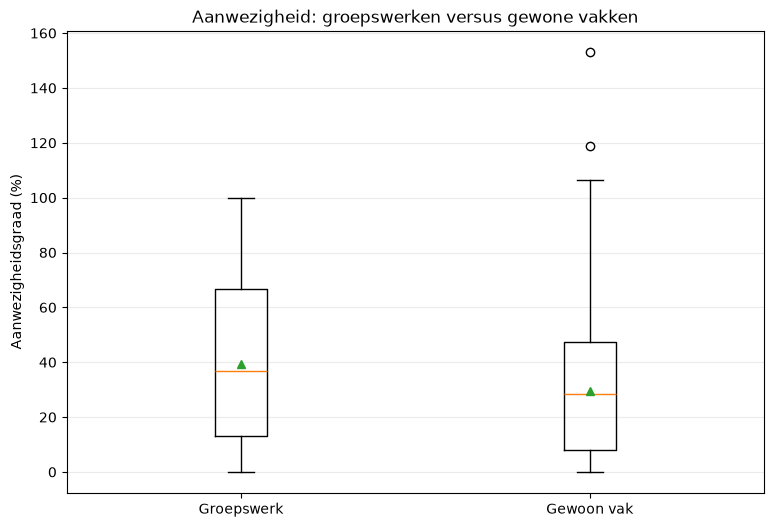

In [ ]:
boxplot_values = [
    analysis_df.loc[
        analysis_df["LessonType"] == lesson_type,
        "AttendancePercentage",
    ].dropna()
    for lesson_type in ["Groepswerk", "Gewoon vak"]
]

plt.figure(figsize=(9, 6))
plt.boxplot(
    boxplot_values,
    tick_labels=["Groepswerk", "Gewoon vak"],
    showmeans=True,
)
plt.ylabel("Aanwezigheidsgraad (%)")
plt.title("Aanwezigheid: groepswerken versus gewone vakken")
plt.grid(axis="y", alpha=0.25)
plt.show()

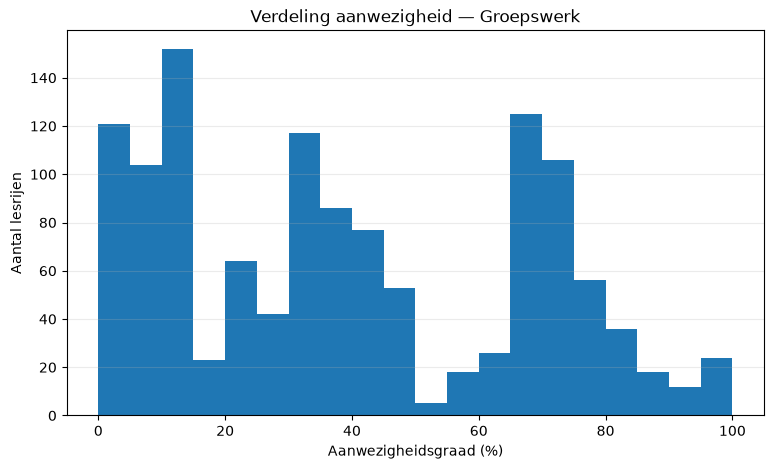

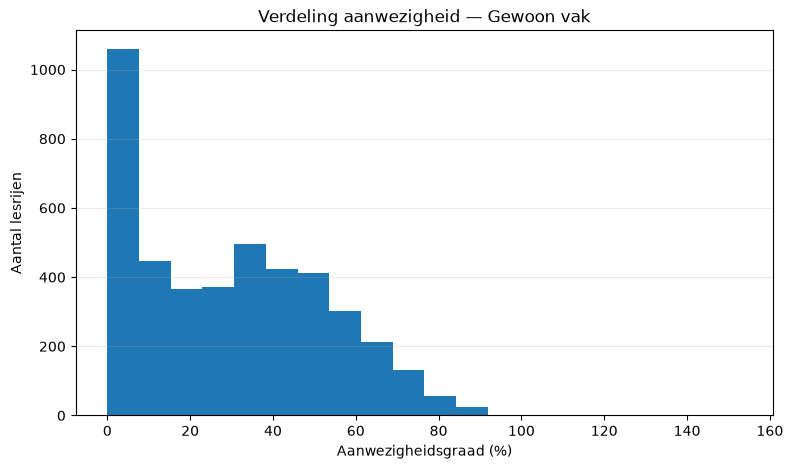

In [ ]:
for lesson_type in ["Groepswerk", "Gewoon vak"]:
    values = analysis_df.loc[
        analysis_df["LessonType"] == lesson_type,
        "AttendancePercentage",
    ].dropna()

    plt.figure(figsize=(9, 5))
    plt.hist(values, bins=20)
    plt.xlabel("Aanwezigheidsgraad (%)")
    plt.ylabel("Aantal lesrijen")
    plt.title(f"Verdeling aanwezigheid — {lesson_type}")
    plt.grid(axis="y", alpha=0.25)
    plt.show()

## 17. Controle op uitschieters

In [ ]:
detail_columns = [
    "FullDate", "LectureID", "ClassName", "SubgroupCode",
    "LessonType", "TotalStudents", "UserCount", "AttendanceRate",
]

lowest = (
    analysis_df[detail_columns]
    .sort_values("AttendanceRate")
    .head(30)
)

highest = (
    analysis_df[detail_columns]
    .sort_values("AttendanceRate", ascending=False)
    .head(30)
)

print("Laagste aanwezigheden")
display(lowest)

print("Hoogste aanwezigheden")
display(highest)

lowest.to_csv(
    OUTPUT_DIR / "lowest_attendance.csv",
    index=False,
    encoding="utf-8-sig",
)

highest.to_csv(
    OUTPUT_DIR / "highest_attendance.csv",
    index=False,
    encoding="utf-8-sig",
)

Laagste aanwezigheden


,FullDate,LectureID,ClassName,SubgroupCode,LessonType,TotalStudents,UserCount,AttendanceRate
5583,2026-05-22,491118,Operating Systems,PBA-TIN-TI/1E,Gewoon vak,32,0,0.0000
39,2025-09-23,387614,Classic Computer Science Algorithms,PBA-TIN-TI/2F,Gewoon vak,26,0,0.0000
40,2025-09-23,387614,Classic Computer Science Algorithms,PBA-TIN-TI/VT/NET/S1,Gewoon vak,26,0,0.0000
41,2025-09-23,395886,IT Fundamentals,PBA-TIN-TI/1B,Gewoon vak,31,0,0.0000
42,2025-09-23,395886,IT Fundamentals,PBA-TIN-TI/VT/PROG/S1,Gewoon vak,31,0,0.0000
43,2025-09-23,396357,Machine Learning Operations,PBA-TIN-TI/3C1,Gewoon vak,36,0,0.0000
44,2025-09-23,394499,Relational Databases & Datawarehousing,PBA-TIN-TI/2B,Gewoon vak,11,0,0.0000
45,2025-09-23,472102,Business analysis,PBA-TIN-TI/3A1,Gewoon vak,25,0,0.0000
46,2025-09-23,472102,Business analysis,PBA-TIN-TI/3A2,Gewoon vak,25,0,0.0000
47,2025-09-23,472066,Business analysis,PBA-TIN-TI/3B1,Gewoon vak,21,0,0.0000


Hoogste aanwezigheden


,FullDate,LectureID,ClassName,SubgroupCode,LessonType,TotalStudents,UserCount,AttendanceRate
733,2025-10-15,471440,Object-oriented Software Development I,PBA-TIN-TI/1H,Gewoon vak,32,49,1.5312
732,2025-10-15,381727,Object-oriented Software Development I,PBA-TIN-TI/1B,Gewoon vak,32,38,1.1875
741,2025-10-15,382294,Object-oriented Software Development I,PBA-TIN-TI/1E,Gewoon vak,31,33,1.0645
1706,2025-11-21,394712,DevOps Project: Operations,PBA-TIN-TI/3B2,Groepswerk,24,24,1.0000
1509,2025-11-14,394711,DevOps Project: Operations,PBA-TIN-TI/VT/NET/S1,Groepswerk,24,24,1.0000
1507,2025-11-14,394711,DevOps Project: Operations,PBA-TIN-TI/3B1,Groepswerk,24,24,1.0000
1705,2025-11-21,394712,DevOps Project: Operations,PBA-TIN-TI/3B1,Groepswerk,24,24,1.0000
1707,2025-11-21,394712,DevOps Project: Operations,PBA-TIN-TI/VT/NET/S1,Groepswerk,24,24,1.0000
1508,2025-11-14,394711,DevOps Project: Operations,PBA-TIN-TI/3B2,Groepswerk,24,24,1.0000
581,2025-10-10,394706,DevOps Project: Operations,PBA-TIN-TI/3B1,Groepswerk,24,24,1.0000


## 18. Resultaten exporteren

In [ ]:
analysis_df.to_csv(
    OUTPUT_DIR / "attendance_with_lesson_type.csv",
    index=False,
    encoding="utf-8-sig",
)

attendance_candidates.to_csv(
    OUTPUT_DIR / "attendance_source_candidates.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"Resultaten opgeslagen in:\n{OUTPUT_DIR}\n")

for file_path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", file_path.name)

Resultaten opgeslagen in:
D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\processed\CourseTypeAnalysis

- attendance_source_candidates.csv
- attendance_with_lesson_type.csv
- group_vs_regular_comparison.csv
- highest_attendance.csv
- lowest_attendance.csv
- metrics_by_course.csv
- metrics_by_lesson_type.csv
- unmatched_course_titles.csv
